<a href="https://colab.research.google.com/github/yaelglz/modelos-estocasticos-toma-decisiones/blob/main/expo/expo_regresion_multiple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ciencias Ambientales: Consumo Energetico

**Objetivo:** Predecir el consumo de energia segun temperatura y humedad.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import warnings

df_env = pd.DataFrame({
    'Temp': [10, 15, 20, 25, 30, 35, 40, 45, 50, 55],
    'Hum': [30, 35, 40, 45, 50, 55, 60, 65, 70, 75],
    'Consumo': [200, 230, 270, 300, 340, 380, 420, 460, 500, 550]
})
display(df_env)

,Temp,Hum,Consumo
0,10,30,200
1,15,35,230
2,20,40,270
3,25,45,300
4,30,50,340
5,35,55,380
6,40,60,420
7,45,65,460
8,50,70,500
9,55,75,550


In [2]:
X_env = df_env[['Temp', 'Hum']]
model_env = LinearRegression().fit(X_env, df_env['Consumo'])

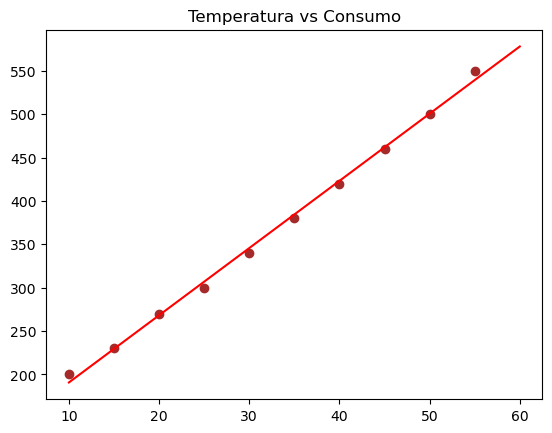

In [3]:
plt.scatter(df_env['Temp'], df_env['Consumo'], color='brown')
x_r = np.linspace(10, 60, 100)
X_plot_env = pd.DataFrame({'Temp': x_r, 'Hum': 30 + (x_r-10)})
plt.plot(x_r, model_env.predict(X_plot_env), color='red')
plt.title('Temperatura vs Consumo')
plt.show()

### Prediccion Requerida
Prediccion para Temperatura=32° y Humedad=52%: 32, 52

In [4]:
pred_init = model_env.predict(pd.DataFrame([[32, 52]], columns=X_env.columns))[0]
print(f'Resultado de la prediccion: Consumo Energetico = {pred_init:.2f} kWh')

Resultado de la prediccion: Consumo Energetico = 361.13 kWh


**Interpretacion:** El modelo estima el consumo energetico basado en la relacion lineal con la temperatura y humedad.

### a) Consumo estimado (37°C, 58%)


In [5]:
pa = model_env.predict(pd.DataFrame([[37, 58]], columns=X_env.columns))[0]
print(f'Consumo estimado: {pa:.2f} kWh')

Consumo estimado: 403.73 kWh


**Interpretacion:** Se proyecta un consumo de 403.37 kWh (aprox) para estas condiciones ambientales.


### b) Humedad +5%


In [6]:
base_b = model_env.predict(pd.DataFrame([[30, 50]], columns=X_env.columns))[0]
new_b = model_env.predict(pd.DataFrame([[30, 55]], columns=X_env.columns))[0]
print(f'Cambio en consumo: {new_b - base_b:.2f} kWh')


Cambio en consumo: 19.36 kWh


**Interpretacion:** Un incremento del 5% en la humedad impacta linealmente el consumo segun su coeficiente.

### c) Minimizacion de consumo


In [7]:
min_idx = df_env['Consumo'].idxmin()
print(f'Consumo minimo observado: {df_env.loc[min_idx, "Consumo"]} kWh')
print(f'Condiciones: {df_env.loc[min_idx, "Temp"]}°C, {df_env.loc[min_idx, "Hum"]}%')


Consumo minimo observado: 200 kWh
Condiciones: 10°C, 30%


**Interpretacion:** El consumo se minimiza en los valores base de 10°C y 30% de humedad, donde la demanda energetica es menor.


### d) Influencia Temp vs Hum


In [8]:
print(f'Impacto +1C Temp: {model_env.coef_[0]:.4f}')
print(f'Impacto +1% Hum: {model_env.coef_[1]:.4f}')


Impacto +1C Temp: 3.8727
Impacto +1% Hum: 3.8727


**Interpretacion:** Comparando el impacto de la temperatura no tiene una diferencia significativa en el consumo.


### e) Humedad para 500 kWh (45°C)


In [9]:
# 500 = beta0 + beta1*45 + beta2*hum
beta0 = model_env.intercept_
beta1, beta2 = model_env.coef_
hum_needed = (500 - beta0 - beta1*45) / beta2
print(f'Humedad necesaria: {hum_needed:.2f}%')


Humedad necesaria: 74.86%


**Interpretacion:** A una temperatura de 45°C, se requeriria una humedad de aproximadamente 74.86% para alcanzar los 500 kWh de consumo.
